# 01 · EDA elemental del dataset Rainfall-Runoff

In [1]:
import json
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.4g}".format)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
SEED = 2025
rng = np.random.default_rng(SEED)

## 1. Estructura

In [2]:
meta = json.loads((RAW / "metadata.json").read_text())
CHANNELS = [c["name"] for c in meta["channels"]]
TARGET_CH = meta["target_channel"]
print(
    f"history={meta['history_hours']}h  forecast={meta['forecast_hours']}h  target={meta['target']} "
    f"[{meta['target_units']}] (channel {TARGET_CH})"
)
for path in sorted(RAW.iterdir()):
    print(f"{path.name:20s} {path.stat().st_size / 2**20:10.1f} MiB")

history=336h  forecast=48h  target=specific_discharge [mm/h] (channel 11)
metadata.json               0.0 MiB
test.h5                   432.5 MiB
test_targets.csv           16.5 MiB
train.h5                 4841.4 MiB


In [3]:
def describe_h5(path: Path) -> pd.DataFrame:
    """One row per dataset in the HDF5 file: shape, dtype and in-memory size."""
    with h5py.File(path) as h:
        rows = [
            {
                "file": path.name,
                "key": k,
                "shape": h[k].shape,
                "dtype": str(h[k].dtype),
                "size_MiB": h[k].size * h[k].dtype.itemsize / 2**20,
            }
            for k in h
        ]
    return pd.DataFrame(rows)


pd.concat([describe_h5(RAW / "train.h5"), describe_h5(RAW / "test.h5")], ignore_index=True)

,file,key,shape,dtype,size_MiB
0,train.h5,X,"(272142, 336, 12)",float32,4186
1,train.h5,basin_id,"(272142,)",int32,1.038
2,train.h5,split,"(272142,)",uint8,0.2595
3,train.h5,y,"(272142, 48)",float32,49.83
4,train.h5,y_aux,"(272142, 48, 11)",float32,548.1
5,test.h5,X,"(27983, 336, 12)",float32,430.4
6,test.h5,basin_id,"(27983,)",int32,0.1067


In [4]:
t0 = time.perf_counter()
with h5py.File(RAW / "train.h5") as h:
    X = h["X"][:]
    y = h["y"][:]
    y_aux = h["y_aux"][:]
    split = h["split"][:]
    basin = h["basin_id"][:]
with h5py.File(RAW / "test.h5") as h:
    X_test = h["X"][:]
    basin_test = h["basin_id"][:]
y_test = pd.read_csv(RAW / "test_targets.csv")
print(f"loaded in {time.perf_counter() - t0:.1f}s")

IDX = {"train": np.flatnonzero(split == 0), "val": np.flatnonzero(split == 1)}
counts = {"train": len(IDX["train"]), "validation": len(IDX["val"]), "test": len(X_test)}
print("counts:  ", counts)
print("metadata:", meta["samples"])
assert counts == meta["samples"]
assert set(np.unique(split)) == {0, 1}

loaded in 3.0s
counts:   {'train': 254000, 'validation': 18142, 'test': 27983}
metadata: {'train': 254000, 'validation': 18142, 'test': 27983}


In [5]:
# test_targets.csv: Id must be the 0-based row index of test.h5, followed by q_01..q_48.
assert list(y_test.columns) == ["Id"] + [f"q_{i:02d}" for i in range(1, 49)]
assert (y_test["Id"].to_numpy() == np.arange(len(X_test))).all()
Y_TEST = y_test.drop(columns="Id").to_numpy(dtype=np.float32)
print("test_targets:", Y_TEST.shape)

test_targets: (27983, 48)


## 2. Muestras de train y eval

La tabla siguiente indica qué canal es el target y cuáles aparecen también en `y_aux`, la
meteorología del horizonte.

In [6]:
pd.DataFrame(meta["channels"]).set_index("index").drop(columns="units_declared_in_source").assign(
    is_target=lambda d: d.index == TARGET_CH,
    in_y_aux=lambda d: d.index.isin(meta["y_aux_channels"]),
)

,name,description,is_target,in_y_aux
index,,,,
0,convective_fraction,Fraccion convectiva,False,True
1,longwave_radiation,Radiacion de onda larga,False,True
2,potential_energy,Energia potencial,False,True
3,potential_evaporation,Evaporacion potencial,False,True
4,pressure,Presion,False,True
5,shortwave_radiation,Radiacion de onda corta,False,True
6,specific_humidity,Humedad especifica,False,True
7,temperature,Temperatura,False,True
8,total_precipitation,Precipitacion total,False,True


Una ventana al azar de cada split, como DataFrame indexado por hora relativa `t`. `t ≤ 0` es la
historia (`X`, 336 h) y `t > 0` el horizonte (48 h).

In [7]:
def window_frame(
    x: np.ndarray, q_future: np.ndarray, aux_future: np.ndarray | None = None
) -> pd.DataFrame:
    """One sample as a table: rows = relative hour t (t <= 0 history, t > 0 horizon).

    x: (336, 12) history; q_future: (48,) discharge; aux_future: (48, 11) or None (test).
    """
    hist = pd.DataFrame(x, columns=CHANNELS, index=np.arange(1 - len(x), 1))
    fut = pd.DataFrame(np.nan, columns=CHANNELS, index=np.arange(1, len(q_future) + 1))
    fut[CHANNELS[TARGET_CH]] = q_future
    if aux_future is not None:
        fut[[CHANNELS[c] for c in meta["y_aux_channels"]]] = aux_future
    frame = pd.concat([hist, fut])
    frame.index.name = "t"
    return frame


def preview(frame: pd.DataFrame, n: int = 3) -> pd.DataFrame:
    """Head, the history/horizon boundary and tail of a window_frame."""
    return pd.concat([frame.head(n), frame.loc[1 - n : n], frame.tail(n)])


sample_rng = np.random.default_rng(SEED)  # keep the shared rng untouched for later cells
samples = {s: int(sample_rng.choice(IDX[s])) for s in ["train", "val"]}
samples["test"] = int(sample_rng.integers(len(X_test)))
print(
    {s: f"row {i}, basin {(basin_test if s == 'test' else basin)[i]}" for s, i in samples.items()}
)

{'train': 'row 121779, basin 241', 'val': 'row 270714, basin 118', 'test': 'row 27775, basin 295'}


In [8]:
i = samples["train"]
preview(window_frame(X[i], y[i], y_aux[i]))

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,specific_discharge
t,,,,,,,,,,,,
-335,0,283.3,0,0.138,1.005e+05,0,0.006282,17.21,0,0.1182,-0.417,0.02591
-334,0,283.3,0,0.002089,1.006e+05,0,0.006158,16.33,0,0.0454,-0.6609,0.02591
-333,0,283.3,0,0.002089,1.007e+05,0,0.006035,15.44,0,-0.03166,-0.8992,0.02591
-2,0,323.8,0,0.5691,1.001e+05,352.4,0.008138,23.61,0,-0.1539,1.856,0.02804
-1,0,323.8,0,0.1224,1.002e+05,184.4,0.008243,21.5,0,-0.615,2.389,0.02743
0,0,323.8,0,0.1224,1.002e+05,0,0.008348,19.39,0,-1.08,2.926,0.02743
1,0,307.1,0,0.1224,1.003e+05,0,0.008453,17.28,0,-1.545,3.464,0.02743
2,0,307.1,0,0.009357,1.003e+05,0,0.008368,16.29,0,-1.422,3.404,0.02743
3,0,307.1,0,0.009357,1.003e+05,0,0.008282,15.31,0,-1.291,3.343,0.02773


In [9]:
i = samples["val"]
preview(window_frame(X[i], y[i], y_aux[i]))

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,specific_discharge
t,,,,,,,,,,,,
-335,0,235.5,1.467,-0.009959,9.666e+04,0,0.004838,4.183,0,0.8652,-5.046,0.006635
-334,0,235.5,0.7345,-0.009959,9.671e+04,0,0.004684,3.569,0,0.8145,-4.819,0.006635
-333,0,230.1,0,-0.009959,9.677e+04,0,0.00453,2.957,0,0.763,-4.587,0.006683
-2,0,229,0,0.00121,9.689e+04,0,0.003211,4.185,0,1.472,2.224,0.01077
-1,0,229,0,0.00121,9.693e+04,0,0.003154,3.804,0,1.697,1.63,0.01077
0,0,224.1,0,0.00121,9.697e+04,0,0.003097,3.422,0,1.923,1.035,0.01077
1,0,224.1,0,-0.002704,9.695e+04,0,0.003052,2.776,0,1.799,1.464,0.01077
2,0,224.1,0,-0.002704,9.693e+04,0,0.003008,2.127,0,1.679,1.895,0.01077
3,0,220.7,0,-0.002704,9.69e+04,0,0.002963,1.478,0,1.557,2.324,0.01064


In [10]:
i = samples["test"]
preview(window_frame(X_test[i], Y_TEST[i]))

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,specific_discharge
t,,,,,,,,,,,,
-335,0,323.8,75.65,0.7286,7.043e+04,630.2,0.004885,18.95,0,1.097,0.464,0.3805
-334,0.3231,338.8,61.82,0.7286,7.042e+04,562.7,0.004726,18.79,0.3031,1.255,-0.246,0.372
-333,0.5989,338.8,70.52,0.6147,7.037e+04,502.5,0.004736,18.54,1.814,1.139,-0.1413,0.3804
-2,0,294.2,45.65,0.5266,6.983e+04,606.8,0.005773,16.26,0,6.007,0.6962,0.3848
-1,0.09153,299.3,46.2,0.5266,6.984e+04,754.9,0.00559,17.57,0.0001278,6.487,0.6862,0.3961
0,0.1747,299.3,31.95,0.8669,6.986e+04,772.9,0.005214,17.95,0.3399,6.839,-0.0289,0.3827
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3621
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3759
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3653


## 3. Calidad de datos

Por canal y split: NaN, infinitos, valores `≤ -999` (centinelas típicos), fracción de ceros y de negativos,
y cuantiles.

In [11]:
def channel_summary(
    arr: np.ndarray, names: list[str], idx: np.ndarray | None = None
) -> pd.DataFrame:
    """Quality and descriptive stats per channel.

    arr: (N, T, C) or (N, T) for a single channel; idx selects samples along axis 0.
    """
    if arr.ndim == 2:
        arr = arr[..., None]
    rows = []
    for c, name in enumerate(names):
        v = (arr[:, :, c] if idx is None else arr[idx, :, c]).ravel()
        finite = np.isfinite(v)
        f = v[finite]
        q = np.percentile(f, [0, 1, 50, 99, 100])
        rows.append(
            {
                "channel": name,
                "nan": int(np.isnan(v).sum()),
                "inf": int(np.isinf(v).sum()),
                "<=-999": int((f <= -999).sum()),
                "zero_frac": (f == 0).mean(),
                "neg_frac": (f < 0).mean(),
                "min": q[0],
                "p01": q[1],
                "median": q[2],
                "mean": f.mean(),
                "p99": q[3],
                "max": q[4],
                "std": f.std(),
            }
        )
    return pd.DataFrame(rows).set_index("channel")


summaries = {
    "train": channel_summary(X, CHANNELS, IDX["train"]),
    "val": channel_summary(X, CHANNELS, IDX["val"]),
    "test": channel_summary(X_test, CHANNELS),
}
summaries["train"]

,nan,inf,<=-999,zero_frac,neg_frac,min,p01,median,mean,p99,max,std
channel,,,,,,,,,,,,
convective_fraction,0,0,0,0.8625,0,0,0,0,0.06095,0.9963,1,0.2053
longwave_radiation,0,0,0,0,0,99.99,180.9,311.8,313.4,454.1,532.7,64.26
potential_energy,0,0,0,0.4891,0,0,0,0.03732,204.5,2404,6344,500.8
potential_evaporation,0,0,0,2.602e-05,0.144,-0.8275,-0.02806,0.06858,0.2057,1.017,1.597,0.2703
pressure,0,0,0,0,0,6.483e+04,6.865e+04,9.625e+04,9.355e+04,1.019e+05,1.043e+05,8089
shortwave_radiation,0,0,0,0.4816,0,0,0,20.47,199.9,897.2,1276,265.3
specific_humidity,0,0,0,0,0,3.047e-05,0.001452,0.006577,0.007676,0.01838,0.02699,0.00439
temperature,0,0,0,5.601e-06,0.09255,-32.52,-7.997,13.22,13.23,34.4,47.54,9.861
total_precipitation,0,0,0,0.7711,0,0,0,0,0.1323,3.038,89.39,0.6703


In [12]:
summaries["val"]

,nan,inf,<=-999,zero_frac,neg_frac,min,p01,median,mean,p99,max,std
channel,,,,,,,,,,,,
convective_fraction,0,0,0,0.8604,0,0,0,0,0.06161,0.996,1,0.2063
longwave_radiation,0,0,0,0,0,99.07,177.6,315.1,315.3,452.1,511.8,63.85
potential_energy,0,0,0,0.5123,0,0,0,0,185.8,2312,5794,472.7
potential_evaporation,0,0,0,3.068e-05,0.1541,-0.4901,-0.02911,0.06948,0.2107,1.028,1.484,0.2759
pressure,0,0,0,0,0,6.521e+04,6.887e+04,9.632e+04,9.383e+04,1.019e+05,1.042e+05,7769
shortwave_radiation,0,0,0,0.4831,0,0,0,19.06,201.5,907.9,1230,268
specific_humidity,0,0,0,0,0,5.288e-05,0.00128,0.006904,0.00785,0.01835,0.02619,0.004348
temperature,0,0,0,4.593e-06,0.08535,-32.14,-8.567,13.95,13.74,34.25,44.89,9.85
total_precipitation,0,0,0,0.7812,0,0,0,0,0.1321,3.05,57.28,0.681


In [13]:
summaries["test"]

,nan,inf,<=-999,zero_frac,neg_frac,min,p01,median,mean,p99,max,std
channel,,,,,,,,,,,,
convective_fraction,0,0,0,0.8557,0,0,0,0,0.06342,0.9961,1,0.2089
longwave_radiation,0,0,0,0,0,94.71,176.7,314.2,315.2,451.8,512.1,65.03
potential_energy,0,0,0,0.489,0,0,0,0.04125,226.3,2488,6119,532.3
potential_evaporation,0,0,0,2.35e-05,0.1667,-0.5116,-0.0335,0.06259,0.2011,0.9927,1.52,0.2703
pressure,0,0,0,0,0,6.544e+04,6.875e+04,9.638e+04,9.39e+04,1.02e+05,1.043e+05,7765
shortwave_radiation,0,0,0,0.4856,0,0,0,15.91,199.4,902.9,1225,266.6
specific_humidity,0,0,0,0,0,5.603e-05,0.001332,0.006916,0.008091,0.0189,0.02503,0.00469
temperature,0,0,0,7.232e-06,0.09931,-32.63,-8.719,13.79,13.51,33.69,46.06,10.12
total_precipitation,0,0,0,0.7734,0,0,0,0,0.1369,3.085,79.36,0.7063


Lo mismo para los targets `y`, `test_targets.csv` y `y_aux` (meteorología futura, solo supervisión).

In [14]:
pd.concat(
    {
        "y train": channel_summary(y[..., None], ["q"], IDX["train"]),
        "y val": channel_summary(y[..., None], ["q"], IDX["val"]),
        "y test": channel_summary(Y_TEST[..., None], ["q"]),
    }
)

,,nan,inf,<=-999,zero_frac,neg_frac,min,p01,median,mean,p99,max,std
,channel,,,,,,,,,,,,
y train,q,0,0,0,0.03258,0,0,0,0.02072,0.06619,0.6804,27.32,0.1612
y val,q,0,0,0,0.03814,0,0,0,0.0222,0.06714,0.7278,12.21,0.1716
y test,q,0,0,0,0.02701,0,0,0,0.02453,0.07442,0.7535,16.28,0.1673


In [15]:
aux_names = [CHANNELS[c] for c in meta["y_aux_channels"]]
channel_summary(y_aux, aux_names, IDX["train"])

,nan,inf,<=-999,zero_frac,neg_frac,min,p01,median,mean,p99,max,std
channel,,,,,,,,,,,,
convective_fraction,0,0,0,0.8625,0,0,0,0,0.06097,0.9962,1,0.2054
longwave_radiation,0,0,0,0,0,102.3,180.8,311.9,313.4,454.2,532.7,64.32
potential_energy,0,0,0,0.4891,0,0,0,0.03787,204.8,2403,6344,501.2
potential_evaporation,0,0,0,2.633e-05,0.1437,-0.5747,-0.02797,0.06824,0.2055,1.017,1.597,0.2703
pressure,0,0,0,0,0,6.496e+04,6.866e+04,9.625e+04,9.355e+04,1.019e+05,1.043e+05,8088
shortwave_radiation,0,0,0,0.4827,0,0,0,19.13,198.9,897.4,1226,264.8
specific_humidity,0,0,0,0,0,8.862e-05,0.001432,0.006588,0.00768,0.01838,0.02634,0.004397
temperature,0,0,0,5.249e-06,0.09469,-32.52,-8.155,13.23,13.21,34.39,46.7,9.895
total_precipitation,0,0,0,0.7707,0,0,0,0,0.133,3.06,89.39,0.6742


**Ventanas planas.** Si el caudal de la historia no varía nada en las 336 h, puede ser un hueco
rellenado (valor repetido) y no una observación real.

In [16]:
def flat_frac(q: np.ndarray) -> float:
    """Fraction of windows (rows of q) with zero range."""
    return float((np.ptp(q, axis=1) == 0).mean())


pd.DataFrame(
    {
        "history (X[..., target])": {
            "train": flat_frac(X[IDX["train"], :, TARGET_CH]),
            "val": flat_frac(X[IDX["val"], :, TARGET_CH]),
            "test": flat_frac(X_test[:, :, TARGET_CH]),
        },
        "forecast (y)": {
            "train": flat_frac(y[IDX["train"]]),
            "val": flat_frac(y[IDX["val"]]),
            "test": flat_frac(Y_TEST),
        },
    }
)

,"history (X[..., target])",forecast (y)
train,0.02394,0.04112
val,0.02943,0.04244
test,0.02051,0.03034


**Distribuciones por canal** (histograma sobre 5 000 ventanas aleatorias de train, eje y logarítmico).

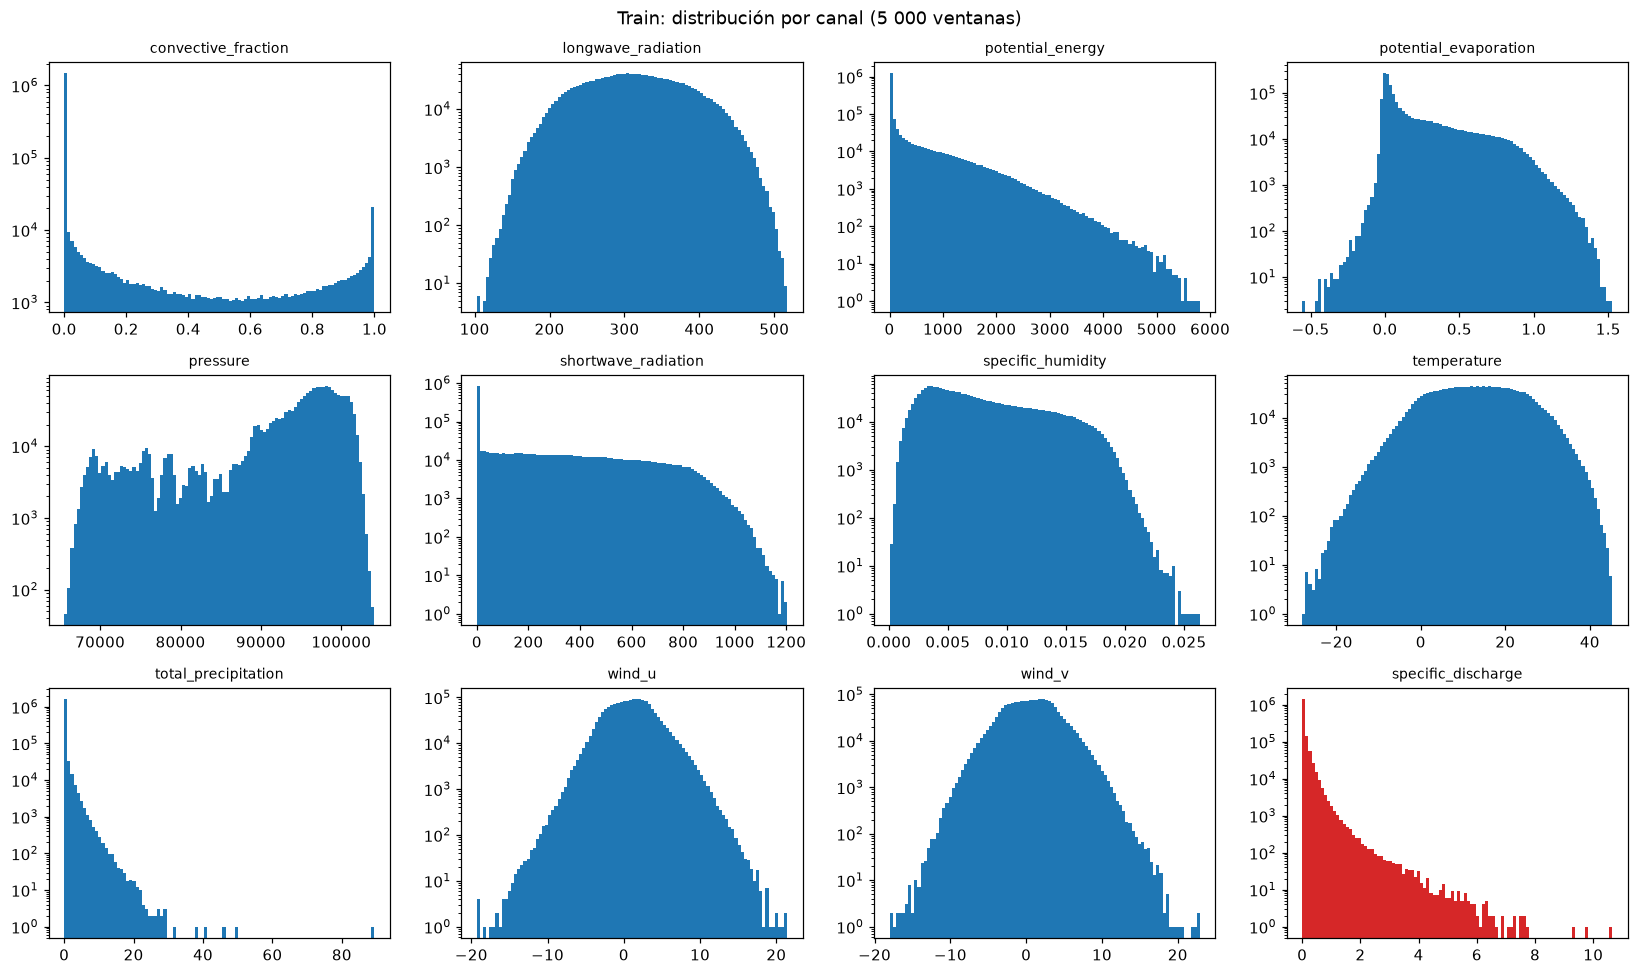

In [17]:
sample = rng.choice(IDX["train"], size=5000, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for c, ax in enumerate(axes.flat):
    ax.hist(X[sample, :, c].ravel(), bins=100, color="C0" if c != TARGET_CH else "C3")
    ax.set_yscale("log")
    ax.set_title(CHANNELS[c], fontsize=9)
fig.suptitle("Train: distribución por canal (5 000 ventanas)")
fig.tight_layout()

## 4. Cuencas

In [18]:
split_basins = {"train": basin[IDX["train"]], "val": basin[IDX["val"]], "test": basin_test}
basin_counts = {k: pd.Series(v).value_counts() for k, v in split_basins.items()}
per_basin = pd.DataFrame(basin_counts).fillna(0).astype(int).sort_index()
per_basin.index.name = "basin_id"

print("basins per split:", {k: len(np.unique(v)) for k, v in split_basins.items()})
print("basin_id range:", per_basin.index.min(), "-", per_basin.index.max())
all_b = set(per_basin.index)
for k, v in split_basins.items():
    missing = sorted(all_b - set(np.unique(v)))
    print(f"basins missing from {k}: {len(missing)} {missing[:10]}")
per_basin.describe()

basins per split: {'train': 508, 'val': 508, 'test': 508}
basin_id range: 0 - 507
basins missing from train: 0 []
basins missing from val: 0 []
basins missing from test: 0 []


,train,val,test
count,508,508,508
mean,500,35.71,55.08
std,0,5.375,7.359
min,500,11,21
25%,500,33,52
50%,500,38,60
75%,500,40,60
max,500,40,60


,train,val,test
count,508,508,508
mean,0.8467,0.06031,0.09303
std,0.01743,0.00824,0.01107
min,0.8333,0.02068,0.03947
25%,0.8333,0.05593,0.08885
50%,0.8389,0.06383,0.1
75%,0.8547,0.06667,0.1
max,0.9398,0.06957,0.1034


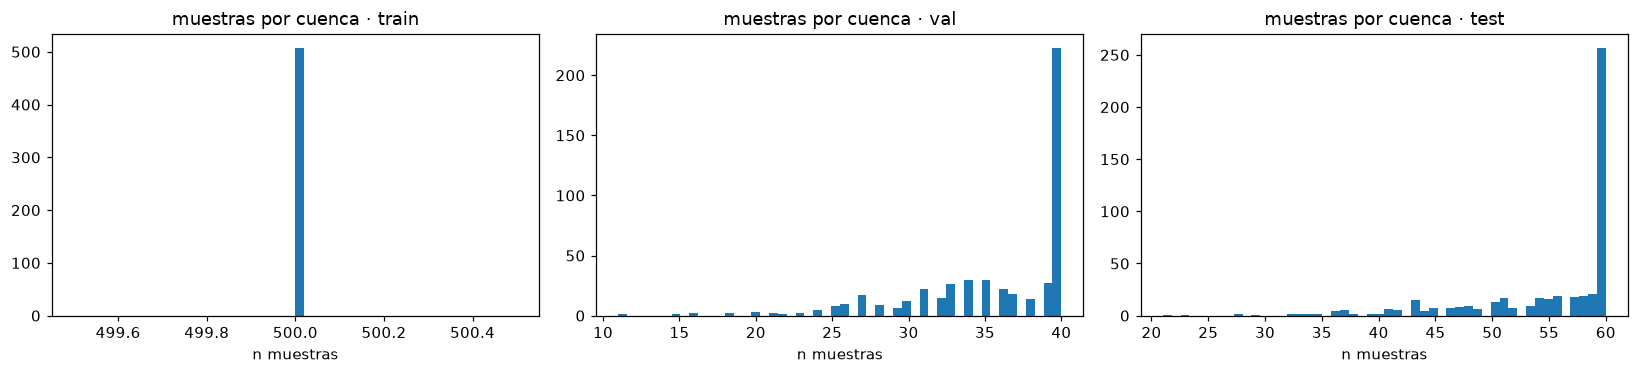

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, per_basin.columns):
    ax.hist(per_basin[col], bins=50)
    ax.set_title(f"muestras por cuenca · {col}")
    ax.set_xlabel("n muestras")
fig.tight_layout()

share = per_basin.div(per_basin.sum(axis=1), axis=0)
share.describe()

## 5. Target: `specific_discharge`

Distribución global del caudal a predecir (`y`) y su escala por cuenca, que sirve de insumo para decidir
la normalización (D-007).

zeros: 3.26%   skewness: 12.9
quantiles: {'p50': np.float64(0.0207), 'p90': np.float64(0.1628), 'p99': np.float64(0.6804), 'p99.9': np.float64(1.8499), 'max': np.float64(27.3241)}


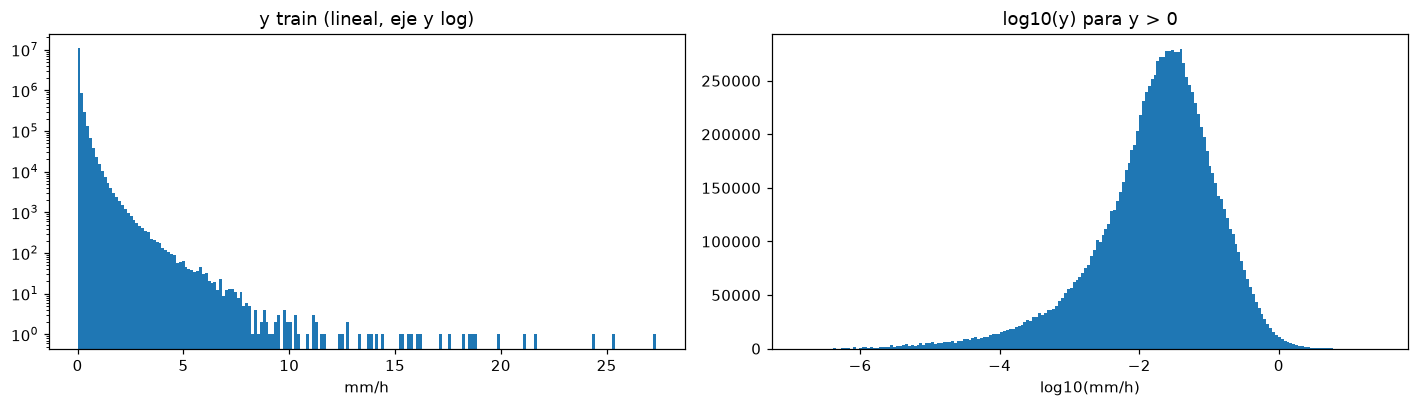

In [20]:
q_train = y[IDX["train"]].ravel()
pos = q_train[q_train > 0]
print(f"zeros: {(q_train == 0).mean():.2%}   skewness: {pd.Series(q_train[::10]).skew():.1f}")
print(
    "quantiles:",
    dict(
        zip(
            ["p50", "p90", "p99", "p99.9", "max"],
            np.percentile(q_train, [50, 90, 99, 99.9, 100]).round(4),
        )
    ),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(q_train, bins=200)
axes[0].set_yscale("log")
axes[0].set_title("y train (lineal, eje y log)")
axes[0].set_xlabel("mm/h")
axes[1].hist(np.log10(pos), bins=200)
axes[1].set_title("log10(y) para y > 0")
axes[1].set_xlabel("log10(mm/h)")
fig.tight_layout()

In [21]:
qs = [1, 10, 50, 90, 99, 99.9]
pd.DataFrame(
    {
        "train": np.percentile(y[IDX["train"]], qs),
        "val": np.percentile(y[IDX["val"]], qs),
        "test": np.percentile(Y_TEST, qs),
    },
    index=[f"p{q}" for q in qs],
)

,train,val,test
p1,0,0,0
p10,0.0007194,0.0008225,0.001126
p50,0.02072,0.0222,0.02453
p90,0.1628,0.154,0.184
p99,0.6804,0.7278,0.7535
p99.9,1.85,2.067,1.84


**Escala por cuenca.** Media, desviación estándar y máximo del caudal en train por cuenca (a partir de las
ventanas de `y`).

In [22]:
yt = y[IDX["train"]]
win = pd.DataFrame(
    {
        "basin_id": basin[IDX["train"]],
        "m1": yt.mean(1),
        "m2": (yt.astype(np.float64) ** 2).mean(1),
        "mx": yt.max(1),
    }
)
g = win.groupby("basin_id")
basin_q = pd.DataFrame({"mean": g["m1"].mean(), "max": g["mx"].max()})
basin_q["std"] = np.sqrt(np.maximum(g["m2"].mean() - basin_q["mean"] ** 2, 0))
basin_q["cv"] = basin_q["std"] / basin_q["mean"]
basin_q.describe(percentiles=[0.05, 0.5, 0.95])

,mean,max,std,cv
count,508,508,508,508
mean,0.06619,2.712,0.1184,2.715
std,0.06502,3.002,0.08807,2.724
min,0.0001405,0.03111,0.001064,0.2926
5%,0.003443,0.2174,0.0145,0.9584
50%,0.04716,1.922,0.1007,1.81
95%,0.2321,7.544,0.3085,6.659
max,0.3821,27.32,0.5543,29.77


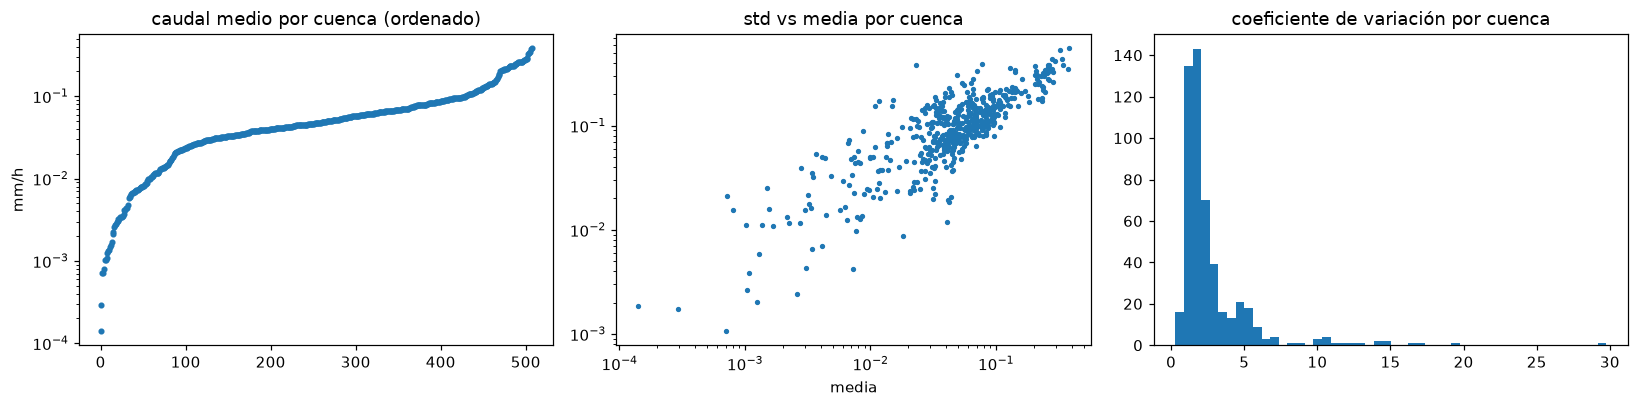

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(np.sort(basin_q["mean"].to_numpy()), marker=".", lw=0)
axes[0].set_yscale("log")
axes[0].set_title("caudal medio por cuenca (ordenado)")
axes[0].set_ylabel("mm/h")
axes[1].scatter(basin_q["mean"], basin_q["std"], s=6)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("std vs media por cuenca")
axes[1].set_xlabel("media")
axes[2].hist(basin_q["cv"], bins=50)
axes[2].set_title("coeficiente de variación por cuenca")
fig.tight_layout()

## 6. Hallazgos

**Estructura**
- Los conteos coinciden con `metadata.json`: 254 000 train, 18 142 val y 27 983 test. `test_targets.csv`
  está alineado fila a fila con `test.h5` (`Id` = índice de fila).
- `train.h5` cabe en memoria (~4.8 GiB) y carga en segundos.

**Calidad**
- **No hay NaN, infinitos ni centinelas (`≤ -999`)** en ningún canal ni split, ni en `y`, `y_aux` o
  `test_targets.csv`. El dataset declara `imputation_applied: false`, así que o no había huecos o las
  ventanas con huecos se descartaron al construirlo.
- ~2–4 % de las ventanas tienen el caudal completamente **plano**. Es del mismo orden que la fracción de
  ceros del caudal (~3 %), así que probablemente son periodos sin flujo, aunque también podrían ser huecos
  rellenados. Queda por revisar.
- Las escalas de los canales son muy distintas: `pressure` ~10⁵ y `specific_humidity` ~10⁻². Hay que
  normalizar por canal.
- `potential_evaporation` tiene ~14 % de valores negativos. Es físicamente posible (condensación/rocío),
  así que no es un error.
- Las distribuciones de train, val y test son muy parecidas; test tiene un caudal algo mayor
  (mediana 0.0245 vs 0.0207).

**Cuencas**
- Hay **508 cuencas**, todas presentes en los tres splits (`basin_id` 0–507).
- **Train tiene exactamente 500 ventanas por cuenca**: el set está submuestreado y balanceado por cuenca.
  Val tiene 11–40 por cuenca y test 21–60 (~6 % y ~9 % del total por cuenca).

**Target (`specific_discharge`, mm/h)**
- Muy asimétrico: skewness ~13, mediana 0.021, p99 0.68 y máximo 27.3. Tiene ~3 % de ceros exactos y
  ningún negativo.
- La **escala varía más de 3 órdenes de magnitud entre cuencas** (caudal medio de 0.00014 a 0.38 mm/h),
  con coeficiente de variación mediano de 1.8 (hasta ~30).
- Todo esto afecta a D-007: normalizar solo de forma global dejaría las cuencas secas casi en cero. Las
  opciones razonables son normalizar por cuenca y/o aplicar una transformada log (p. ej. `log(q + ε)`,
  con ε > 0 por los ceros). La decisión es del equipo.
